![Local Image](Imagens_e_Recursos/Ilum_Horizontal_com_assinatura.png)

<div style="text-align: center">
    
  <div style="font-size: 32px">
    $$ \text{Rota do Acadêmico} $$
  </div>
  
  <div style="font-size: 24px">
    Redes Neurais e Algoritmos Genéticos - 2026
  </div>  
  
</div>

<br>

<div style="font-size: 18px">
    Aniel de Souza Ribeiro Neto
</div>

<hr>

<div style="text-align: center">
    
  <div style="font-size: 28px";>
    Aprendizado por Transferência em Python
  </div>
  

## 1. Considerações Iniciais

<p style="text-align: justify;"> &emsp; No primeiro notebook do trabalho, aprendemos os fundamentos teóricos do aprendizado por transferência. Vamos agora colocar esses conhecimentos em prática, realizando, passo a passo, os processos de obtenção de um modelo pré treinado, extração de features e <i>fine tuning</i>. Para isso vamos utilizar o <b>Torch</b> como módulo principal para trabalharmos com as redes neurais [1]. Dessa forma, é esperado que o leitor tenha algum conhecimento do fluxo básico de criação, treino e uso de redes neurais no módulo Torch. Se este não for o seu caso, recomendo a leitura do guia de usuário do módulo [2]. Conhecimentos mais avançados serão explicados ao longo do trabalho.</p>

<p style="text-align: justify;"> &emsp; Vamos trabalhar em um problema de classificação multiclasse de imagens, isto é, tentaremos prever a classe correta de cada imagem através da nossa rede neural. O conjunto de imagens utilizado será o <b>CIFAR 10</b> (Tabela 1), um conjunto de 60 mil imagens - divididas em 50 mil de treino e 10 mil de teste - de 10 classes diferentes (carros, caminhões, barcos, aviões, pássaros, cachorros, gatos, sapos e cervos) [3]. Como modelo base utilizaremos o <b>Residual Network 18</b>, que foi previamente treinado para classificação de imagens de 1000 classes diferentes [4].</p>

<table>
    <tbody><tr>
        <td class="cifar-class-name">airplane</td>
        <td><img src="Imagens_e_Recursos/cifar-10-sample/airplane1.png" class="cifar-sample"></td>
        <td><img src="Imagens_e_Recursos/cifar-10-sample/airplane2.png" class="cifar-sample"></td>
        <td><img src="Imagens_e_Recursos/cifar-10-sample/airplane3.png" class="cifar-sample"></td>
        <td><img src="Imagens_e_Recursos/cifar-10-sample/airplane4.png" class="cifar-sample"></td>
        <td><img src="Imagens_e_Recursos/cifar-10-sample/airplane5.png" class="cifar-sample"></td>
        <td><img src="Imagens_e_Recursos/cifar-10-sample/airplane6.png" class="cifar-sample"></td>
        <td><img src="Imagens_e_Recursos/cifar-10-sample/airplane7.png" class="cifar-sample"></td>
        <td><img src="Imagens_e_Recursos/cifar-10-sample/airplane8.png" class="cifar-sample"></td>
        <td><img src="Imagens_e_Recursos/cifar-10-sample/airplane9.png" class="cifar-sample"></td>
        <td><img src="Imagens_e_Recursos/cifar-10-sample/airplane10.png" class="cifar-sample"></td>
    </tr>
    <tr>
        <td class="cifar-class-name">automobile</td>
        <td><img src="Imagens_e_Recursos/cifar-10-sample/automobile1.png" class="cifar-sample"></td>
        <td><img src="Imagens_e_Recursos/cifar-10-sample/automobile2.png" class="cifar-sample"></td>
        <td><img src="Imagens_e_Recursos/cifar-10-sample/automobile3.png" class="cifar-sample"></td>
        <td><img src="Imagens_e_Recursos/cifar-10-sample/automobile4.png" class="cifar-sample"></td>
        <td><img src="Imagens_e_Recursos/cifar-10-sample/automobile5.png" class="cifar-sample"></td>
        <td><img src="Imagens_e_Recursos/cifar-10-sample/automobile6.png" class="cifar-sample"></td>
        <td><img src="Imagens_e_Recursos/cifar-10-sample/automobile7.png" class="cifar-sample"></td>
        <td><img src="Imagens_e_Recursos/cifar-10-sample/automobile8.png" class="cifar-sample"></td>
        <td><img src="Imagens_e_Recursos/cifar-10-sample/automobile9.png" class="cifar-sample"></td>
        <td><img src="Imagens_e_Recursos/cifar-10-sample/automobile10.png" class="cifar-sample"></td>
    </tr>
    <tr>
        <td class="cifar-class-name">bird</td>
        <td><img src="Imagens_e_Recursos/cifar-10-sample/bird1.png" class="cifar-sample"></td>
        <td><img src="Imagens_e_Recursos/cifar-10-sample/bird2.png" class="cifar-sample"></td>
        <td><img src="Imagens_e_Recursos/cifar-10-sample/bird3.png" class="cifar-sample"></td>
        <td><img src="Imagens_e_Recursos/cifar-10-sample/bird4.png" class="cifar-sample"></td>
        <td><img src="Imagens_e_Recursos/cifar-10-sample/bird5.png" class="cifar-sample"></td>
        <td><img src="Imagens_e_Recursos/cifar-10-sample/bird6.png" class="cifar-sample"></td>
        <td><img src="Imagens_e_Recursos/cifar-10-sample/bird7.png" class="cifar-sample"></td>
        <td><img src="Imagens_e_Recursos/cifar-10-sample/bird8.png" class="cifar-sample"></td>
        <td><img src="Imagens_e_Recursos/cifar-10-sample/bird9.png" class="cifar-sample"></td>
        <td><img src="Imagens_e_Recursos/cifar-10-sample/bird10.png" class="cifar-sample"></td>
    </tr>
    <tr>
        <td class="cifar-class-name">cat</td>
        <td><img src="Imagens_e_Recursos/cifar-10-sample/cat1.png" class="cifar-sample"></td>
        <td><img src="Imagens_e_Recursos/cifar-10-sample/cat2.png" class="cifar-sample"></td>
        <td><img src="Imagens_e_Recursos/cifar-10-sample/cat3.png" class="cifar-sample"></td>
        <td><img src="Imagens_e_Recursos/cifar-10-sample/cat4.png" class="cifar-sample"></td>
        <td><img src="Imagens_e_Recursos/cifar-10-sample/cat5.png" class="cifar-sample"></td>
        <td><img src="Imagens_e_Recursos/cifar-10-sample/cat6.png" class="cifar-sample"></td>
        <td><img src="Imagens_e_Recursos/cifar-10-sample/cat7.png" class="cifar-sample"></td>
        <td><img src="Imagens_e_Recursos/cifar-10-sample/cat8.png" class="cifar-sample"></td>
        <td><img src="Imagens_e_Recursos/cifar-10-sample/cat9.png" class="cifar-sample"></td>
        <td><img src="Imagens_e_Recursos/cifar-10-sample/cat10.png" class="cifar-sample"></td>
    </tr>
    <tr>
        <td class="cifar-class-name">deer</td>
        <td><img src="Imagens_e_Recursos/cifar-10-sample/deer1.png" class="cifar-sample"></td>
        <td><img src="Imagens_e_Recursos/cifar-10-sample/deer2.png" class="cifar-sample"></td>
        <td><img src="Imagens_e_Recursos/cifar-10-sample/deer3.png" class="cifar-sample"></td>
        <td><img src="Imagens_e_Recursos/cifar-10-sample/deer4.png" class="cifar-sample"></td>
        <td><img src="Imagens_e_Recursos/cifar-10-sample/deer5.png" class="cifar-sample"></td>
        <td><img src="Imagens_e_Recursos/cifar-10-sample/deer6.png" class="cifar-sample"></td>
        <td><img src="Imagens_e_Recursos/cifar-10-sample/deer7.png" class="cifar-sample"></td>
        <td><img src="Imagens_e_Recursos/cifar-10-sample/deer8.png" class="cifar-sample"></td>
        <td><img src="Imagens_e_Recursos/cifar-10-sample/deer9.png" class="cifar-sample"></td>
        <td><img src="Imagens_e_Recursos/cifar-10-sample/deer10.png" class="cifar-sample"></td>
    </tr>
    <tr>
        <td class="cifar-class-name">dog</td>
        <td><img src="Imagens_e_Recursos/cifar-10-sample/dog1.png" class="cifar-sample"></td>
        <td><img src="Imagens_e_Recursos/cifar-10-sample/dog2.png" class="cifar-sample"></td>
        <td><img src="Imagens_e_Recursos/cifar-10-sample/dog3.png" class="cifar-sample"></td>
        <td><img src="Imagens_e_Recursos/cifar-10-sample/dog4.png" class="cifar-sample"></td>
        <td><img src="Imagens_e_Recursos/cifar-10-sample/dog5.png" class="cifar-sample"></td>
        <td><img src="Imagens_e_Recursos/cifar-10-sample/dog6.png" class="cifar-sample"></td>
        <td><img src="Imagens_e_Recursos/cifar-10-sample/dog7.png" class="cifar-sample"></td>
        <td><img src="Imagens_e_Recursos/cifar-10-sample/dog8.png" class="cifar-sample"></td>
        <td><img src="Imagens_e_Recursos/cifar-10-sample/dog9.png" class="cifar-sample"></td>
        <td><img src="Imagens_e_Recursos/cifar-10-sample/dog10.png" class="cifar-sample"></td>
    </tr>
    <tr>
        <td class="cifar-class-name">frog</td>
        <td><img src="Imagens_e_Recursos/cifar-10-sample/frog1.png" class="cifar-sample"></td>
        <td><img src="Imagens_e_Recursos/cifar-10-sample/frog2.png" class="cifar-sample"></td>
        <td><img src="Imagens_e_Recursos/cifar-10-sample/frog3.png" class="cifar-sample"></td>
        <td><img src="Imagens_e_Recursos/cifar-10-sample/frog4.png" class="cifar-sample"></td>
        <td><img src="Imagens_e_Recursos/cifar-10-sample/frog5.png" class="cifar-sample"></td>
        <td><img src="Imagens_e_Recursos/cifar-10-sample/frog6.png" class="cifar-sample"></td>
        <td><img src="Imagens_e_Recursos/cifar-10-sample/frog7.png" class="cifar-sample"></td>
        <td><img src="Imagens_e_Recursos/cifar-10-sample/frog8.png" class="cifar-sample"></td>
        <td><img src="Imagens_e_Recursos/cifar-10-sample/frog9.png" class="cifar-sample"></td>
        <td><img src="Imagens_e_Recursos/cifar-10-sample/frog10.png" class="cifar-sample"></td>
    </tr>
    <tr>
        <td class="cifar-class-name">horse</td>
        <td><img src="Imagens_e_Recursos/cifar-10-sample/horse1.png" class="cifar-sample"></td>
        <td><img src="Imagens_e_Recursos/cifar-10-sample/horse2.png" class="cifar-sample"></td>
        <td><img src="Imagens_e_Recursos/cifar-10-sample/horse3.png" class="cifar-sample"></td>
        <td><img src="Imagens_e_Recursos/cifar-10-sample/horse4.png" class="cifar-sample"></td>
        <td><img src="Imagens_e_Recursos/cifar-10-sample/horse5.png" class="cifar-sample"></td>
        <td><img src="Imagens_e_Recursos/cifar-10-sample/horse6.png" class="cifar-sample"></td>
        <td><img src="Imagens_e_Recursos/cifar-10-sample/horse7.png" class="cifar-sample"></td>
        <td><img src="Imagens_e_Recursos/cifar-10-sample/horse8.png" class="cifar-sample"></td>
        <td><img src="Imagens_e_Recursos/cifar-10-sample/horse9.png" class="cifar-sample"></td>
        <td><img src="Imagens_e_Recursos/cifar-10-sample/horse10.png" class="cifar-sample"></td>
    </tr>
    <tr>
        <td class="cifar-class-name">ship</td>
        <td><img src="Imagens_e_Recursos/cifar-10-sample/ship1.png" class="cifar-sample"></td>
        <td><img src="Imagens_e_Recursos/cifar-10-sample/ship2.png" class="cifar-sample"></td>
        <td><img src="Imagens_e_Recursos/cifar-10-sample/ship3.png" class="cifar-sample"></td>
        <td><img src="Imagens_e_Recursos/cifar-10-sample/ship4.png" class="cifar-sample"></td>
        <td><img src="Imagens_e_Recursos/cifar-10-sample/ship5.png" class="cifar-sample"></td>
        <td><img src="Imagens_e_Recursos/cifar-10-sample/ship6.png" class="cifar-sample"></td>
        <td><img src="Imagens_e_Recursos/cifar-10-sample/ship7.png" class="cifar-sample"></td>
        <td><img src="Imagens_e_Recursos/cifar-10-sample/ship8.png" class="cifar-sample"></td>
        <td><img src="Imagens_e_Recursos/cifar-10-sample/ship9.png" class="cifar-sample"></td>
        <td><img src="Imagens_e_Recursos/cifar-10-sample/ship10.png" class="cifar-sample"></td>
    </tr>
    <tr>
        <td class="cifar-class-name">truck</td>
        <td><img src="Imagens_e_Recursos/cifar-10-sample/truck1.png" class="cifar-sample"></td>
        <td><img src="Imagens_e_Recursos/cifar-10-sample/truck2.png" class="cifar-sample"></td>
        <td><img src="Imagens_e_Recursos/cifar-10-sample/truck3.png" class="cifar-sample"></td>
        <td><img src="Imagens_e_Recursos/cifar-10-sample/truck4.png" class="cifar-sample"></td>
        <td><img src="Imagens_e_Recursos/cifar-10-sample/truck5.png" class="cifar-sample"></td>
        <td><img src="Imagens_e_Recursos/cifar-10-sample/truck6.png" class="cifar-sample"></td>
        <td><img src="Imagens_e_Recursos/cifar-10-sample/truck7.png" class="cifar-sample"></td>
        <td><img src="Imagens_e_Recursos/cifar-10-sample/truck8.png" class="cifar-sample"></td>
        <td><img src="Imagens_e_Recursos/cifar-10-sample/truck9.png" class="cifar-sample"></td>
        <td><img src="Imagens_e_Recursos/cifar-10-sample/truck10.png" class="cifar-sample"></td>
    </tr>
</tbody></table>
<p style="text-align: center;"><em>Tabela 1: Exemplos de imagens do CIFAR10 [3].</em></p>

<p style="text-align: justify;"> &emsp; É importante manter em mente que, apesar de que iremos estudar apenas um modelo pré treinado neste trabalho, a lógica e fluxo geral de trabalho segue o mesmo para outros modelos. Seria, também, impossível apresentar modelos suficientes para todos os problemas que possam aparecer. Desse modo, as etapas que serão apresentadas aqui terão foco em oferecer idependência ao leitor para que ele possa, por conta própria, procurar novos modelos adequados ao seu problema, carregar e ajustar esse modelo e utilizá-lo para resolver seu problema, ajustando cada parte que será apresentada às condições do seu projeto.</p>


## 2. Conhecendo o Modelo 

<p style="text-align: justify;"> &emsp; Tendo definido um problema em que é adequado o uso de aprendizado por transferência, o primeiro passo é encontrar um modelo que seja compatível a ele. Você pode encontrar modelos em diversas fontes, recomendo, como pesquisa inicial, consultar a documentação do módulo Torch, que possuí uma seção de hub de modelos pré treinados [5]. Alguns pacotes também agregam alguns modelos prontos, por exemplo, modelos pré treinados para o trabalho com imagens, como o ResNet18 que utilizaremos, podem ser encontrados na documentação do pacote <b>Torchvision</b> [6].</p>

<p style="text-align: justify;"> &emsp; Neste estudo, vamos trabalhar com um problema de classificação de imagens do conjunto de dados CIFAR-10. Assim, o modelo escolhido foi o Residual Network 18. Ele foi encontrado através da documentação do Torchvision e foi escolhido pois sua estrutura já se mostrou capaz de ser utilizada com o nosso conjunto de dados na literatura [7]. Apesar de não ser necessário para a utilização do modelo, é sempre importante, para que possamos utilizar com confiança o modelo, conhecermos um pouco seu funcionamento e arquitetura. Dessa forma, vamos olhar brevemente para a estrutura da ResNet18.</p>

<p style="text-align: justify;"> &emsp; As Redes Neurais Residuais, surgiram como uma forma de evitar o problema da degradação da precisão de treino, em que redes profundas perdem sua precisão conforme o aumento no número de camadas devido a fatores como a explosão e desaparecimento do gradiente e a dificuldade de ensinar camadas a resultarem na identidade da entrada (isto é, não alterar o valor quando não for necessário) [7]. Elas resolvem esse problema utilizando blocos de camadas que consideram não apenas o resultado da rede para o treino, mas o resíduo, isto é, a diferença que a saída têm da entrada (Figura 1). Assim, a ResNet18, é uma rede neural convolucional residual de 18 camadas para a previsão de imagens (Figura 2), treinada no ImageNet, um conjunto de dados com mais de 1 milhão de imagens de 1000 classes diferentes. Portanto, a ResNet18, sendo um modelo especializado para <i>deep learning</i> e capaz de prever imagens de diversas classes, se mostra adequado para nosso problema. Agora podemos partir com confiança para a utilização do modelo. </p>

<div style="text-align: center;">
  <img src="Imagens_e_Recursos/residual_block.png"
       style="width: 400px;">
  <p style="text-align: center;"><em>Figura 1: Estrutura de um bloco residual [7].</em></p>
</div>

<div style="text-align: center;">
  <img src="Imagens_e_Recursos/Original-ResNet-18-Architecture.webp"
       style="width: 800px;">
  <p style="text-align: center;"><em>Figura 2: Arquitetura da ResNet18 [8].</em></p>
</div>


## 3. Preparando o Conjunto de Dados 

<p style="text-align: justify;"> &emsp; A primeira etapa para começar a resolver o problema é acessar o conjunto de dados e prepará-lo para ser utilizado pelo modelo. Para essa etapa, utilzaremos o pacote Torchvision para acessar o conjunto de dados e o transformador de dados e o módulo Torch para preparar o carregador de dados. Os códigos desta seção, bem como os das restante, são baseados principalmente nas referência [9] e [10].</p>

In [2]:
import torch
from torchvision.datasets import CIFAR10
from torchvision.transforms import transforms

<p style="text-align: justify;"> &emsp; Mesmo que o modelo tenha sido treinado com dados semelhantes ao seu conjunto de dados, precisamos de que os nossos dados sigam a mesma estrutura que foram utilizadas no treino inicial. Para isso, precisamos de consultar os parâmetros dos dados utilizados no treino inicial, que para modelos do Torch são apresentados na documentação do modelo [4], e ajustar nossos dados para seguir esses parâmetros. Para o trabalho com imagens através do Torchvision, isso pode ser feito construindo um transformador que re-escala, corta, normaliza e converte para tensor nossas imagens seguindo os critérios descritos na fonte do modelo [11]. Vamos construir o transformador utilizando o transforms.Compose do Torchvision, que permite a composição de múltiplas transformações em série em um único transformador [12].</p>

In [3]:
# --- Normalizador para ResNet --- 

transformador = transforms.Compose([
    transforms.Resize(256), # Reescala a imagem para o tamanho indicado
    transforms.CenterCrop(224), # Corta a imagem a partir do centro para um quadrado 224x224
    transforms.ToTensor(), # Converte para tensor [0,1]
    transforms.Normalize(mean=[0.485, 0.456, 0.406], 
                         std=[0.229, 0.224, 0.225]), # Normaliza a imagem para o padrão de treino do modelo
])

<p style="text-align: justify;"> &emsp; Tendo o transformador para ajustar os dados, podemos carregar o nosso conjunto de dados. Esse processo pode variar de acordo com a origem do conjunto de dados, valendo consultar como carregar o conjunto para a sua fonte. Para o caso do Torchvision, a classe CIFAR10 permite o carregamento e download dos dados de treino e teste do conjunto, e aplicação direta do trasnformador construído anteriormente [13]. É possível também construir uma classe semelhante com um conjunto de dados próprio [14].</p>

<p style="text-align: justify;"> &emsp; Como estaremos trabalhando com o módulo Torch, vamos também construir um carregador de dados, que recebe o conjunto de treino ou teste e prepara esse conjunto para ser entregue a um modelo do Torch [15]. Dividiremos nossos conjuntos de treino e teste em <i>batches</i> de 32 imagens através do argumento batch_size, permitindo o treino em <i>batches</i> do modelo.</p>

<p style="text-align: justify;"> &emsp; Por fim, como estamos trabalhando em um problema de classificação, vamos criar também um conjunto contendo as classes do conjunto de dados.</p>

In [4]:
# --- Obtendo o Dataset e Carregando os Dados ---

# Dados de treino
conjunto_treino = CIFAR10( # Carrega o dataset CIFAR10
    root='./data', 
    train=True, # Carrega o grupo de treino do dataset
    download=True,
    transform=transformador, # Aplica o transformador 
)
carregador_treino = torch.utils.data.DataLoader( # Adiciona o dataset de treino a um carregador de dados
    dataset=conjunto_treino,
    batch_size=32, # Dados são divididos em grupos de 32 imagens 
    shuffle=True, 
)

# Dados de teste
conjunto_teste = CIFAR10( # Carrega o dataset CIFAR10
    root='./data', 
    train=False, # Carrega o grupo de teste do dataset
    download=True, 
    transform=transformador, # Aplica o transformador
)
carregador_teste = torch.utils.data.DataLoader( # Adiciona o dataset de teste a um carregador de dados
    dataset=conjunto_teste,
    batch_size=32, # Dados são divididos em grupos de 32 imagens 
    shuffle=True, 
)

# Definindo as classes
classes = ('plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck')

<p style="text-align: justify;"> &emsp; É sempre importante mantermos uma noção da estrutura dos nossos dados. Dessa forma, a célula seguinte permite acessar um <i>batch</i> qualquer do carregador de dados construído anteriormente e apresenta as imagens dele através do módulo matplotlib [9]. Essa etapa não é obrigatória, e se você já conhece a forma dos seus dados você pode ir direto para a próxima parte do processo.</p>

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.558952..1.82].


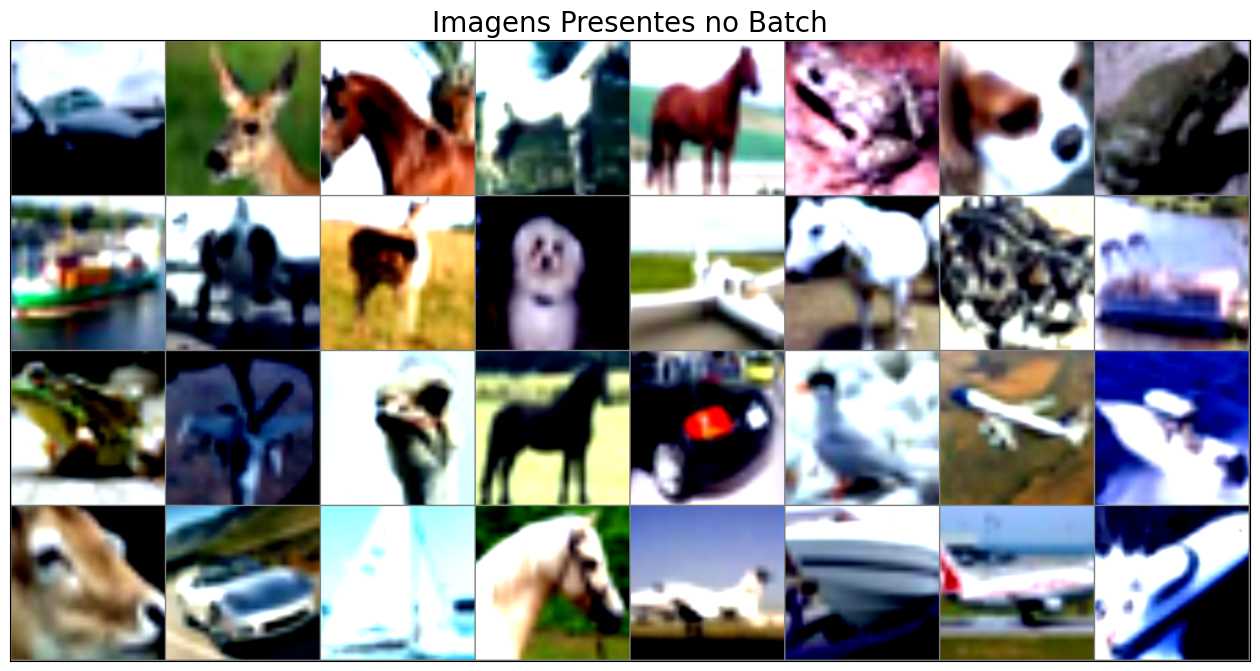

In [5]:
# --- Visualizando um Batch --- 

import matplotlib.pyplot as plt
import numpy as np
from torchvision.utils import make_grid

def imshow(img):
    """Essa função recebe tensores de imagens transformadas e plota um grid com as imagens."""
    img = img / 2 + 0.5
    npimg = img.numpy()
    fig, ax = plt.subplots(figsize=(16,9))
    ax.imshow(np.transpose(npimg, (1, 2, 0)))
    ax.set_title("Imagens Presentes no Batch", fontsize=20)
    ax.set_xticks([])
    ax.set_yticks([])
    plt.show()


# Acessando um batch de imagens aleatórias do conjunto de treino
dataiter = iter(carregador_treino)
images, _ = next(dataiter)

# Mostrando as imagens do batch
imshow(make_grid(images))

## 4. Carregando o Modelo Pré Treinado

<p style="text-align: justify;"> &emsp; Com os conjuntos de dados de treino e teste prontos, podemos partir para o carregamento do modelo. Utilizaremos para essa etapa o subpacote models do Torchvision.</p>

In [7]:
from torchvision import models 

<p style="text-align: justify;"> &emsp; O processo de obtenção do modelo pode variar bastante de acordo com a fonte do modelo, sendo importante pesquisar como carregar o modelo corretamente com os pesos pré treinados. Para o caso dos modelos do Torchvision e hub basta indicar o modelo e os pesos que serão utilizados no argumento weights [4,5]. Utilizaremos neste estudo apenas o método do Torchvision. Assim, para carregar o modelo, simplesmente indicamos qual o modelo presente no subpacote queremos utilizar e qual conjunto de pesos iniciais, indicados na página de cada modelo, desejamos que ele tenha [6]. Para acessarmos os pesos da ResNet18 treinada na ImageNet, utilizaremos models.ResNet18_Weights.DEFAULT no argumento weights. Note que a referência [10] utiliza o argumento pre_trained=True para realizar esse processo, este, entretanto, está obsoleto.</p>

In [8]:
# --- Instânciando o Modelo --- 

resnet = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

print(resnet)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

## 5. Utilizando o Modelo para Extração de Features

<p style="text-align: justify;"> &emsp; Vamos primeiro utilizar o modelo para extração de features, isto é, vamos manter os pesos originais do modelo e alterar a última camada para testar o quão bem o modelo já prevê nossos dados. No Torch, o processo de manter os pesos originais, também chamado de <i>layer freezing</i>, é feito acessando cada parâmetro do modelo, através do método .parameters(), e desativando seu gradiente utilizando o atributo .requires_grad como False.</p>

In [10]:
# --- Congelando a atualização dos parâmetros --- 

for parametro in resnet.parameters(): 
    parametro.requires_grad = False

<p style="text-align: justify;"> &emsp; Podemos então atualizar a última camada do modelo para que o modelo se ajuste ao nosso problema. No nosso caso, substituiremos a última camada do modelo ResNet18, chamada de fc, por uma camada que aplicará um valor para cada classe do nosso problema, que será utilizados para definir qual classe foi prevista pelo modelo. Faremos isso utilizando uma camada linear do Torch, que recebe o mesmo número de dados da camada original, acessado pelo atributo in_features da camada, e entrega a mesma quantidade dados que o nosso número de classes. Fazer isso descongela automáticamente os parâmetros desta camada.</p>

In [11]:
# --- Atualizando a última camada --- 

resnet.fc = torch.nn.Linear(resnet.fc.in_features, len(classes)) # Cria uma camada de saída com o número de classes do problema

<p style="text-align: justify;"> &emsp; Como em qualquer outro processo de treino pelo Torch, definiremos nossa função de perda e otimizador. Como estamos trabalhando em um problema de classificação, vamos utilizar a função de perda de entropia cruzada, <i>CrossEntropyLoss</i>, e a descida estocástica do gradiente, SDG, como otimizador. Caso não esteja habituado a esse processo, bem como ao processo de treino em sequência, recomendo novamente a consulta ao guia de iniciante do Torch [2], uma vez que é esperado que o leitor entenda razoavelmente bem esses processos.</p>

In [12]:
# --- Criando o otimizador e função de perda --- 

import torch.optim as optim 

# Função de perda 
fperda = torch.nn.CrossEntropyLoss() 
# Otimizador 
otimizador_feature_extractor = optim.SGD(resnet.fc.parameters(), lr=1e-3, momentum=0.9)

<p style="text-align: justify;"> &emsp; Podemos enfim ajustar a última camada aos nossos dados treinando o modelo. Como congelamos os pesos das outras camdas anteriormente, apenas a última camada será ajustada. Vamos utilizar um <i>loop</i> básico de treino em <i>batches</i> de redes neurais em Torch, em que treinaremos o modelo por 5 épocas, uma vez que este é um trabalho de fins puramente didáticos e esse número deve ser ajustado de acordo com o seu problema, apresentando a perda de cada época.</p>

In [13]:
# --- Treinando o modelo ---
for epoca in range(5): # Realiza o treino por 5 épocas 
    
    perda_epoca = 0 # Perda acumlativa da época
    
    for batch in carregador_treino: # Acessa todos os batches de treino
        dados, rotulos = batch # Separa os pares dado-classe 

        # Zerando o gradiente 
        otimizador_feature_extractor.zero_grad()
        # Realizando o FowardPass
        previsao = resnet(dados)
        # Calculando a perda 
        perda = fperda(previsao, rotulos)
        # Fazendo o backpropagation
        perda.backward()
        # Ajustando os parâmetros
        otimizador_feature_extractor.step()

        # Adicionando a perda à contagem 
        perda_epoca += perda.item()

    print(f"Época: {epoca + 1} | Perda: {perda_epoca/len(carregador_treino)}") # Apresentando a época e sua perda média

print("--- Treino Finalizado ---")

Época: 1 | Perda: 0.9527647975005176
Época: 2 | Perda: 0.7366373029109079
Época: 3 | Perda: 0.7004249507676922
Época: 4 | Perda: 0.6877751474531507
Época: 5 | Perda: 0.6745364224670487
--- Treino Finalizado ---


<p style="text-align: justify;"> &emsp; Por fim, testaremos o modelo utilizando os dados de teste para ver se ele foi capaz de se adequar ao nosso problema. Para isso vamos utilizar um <i>loop</i> de previsão por <i>batches</i> e calculando a razão de acertos e previsões de cada <i>batche</i> considerando o rótulo previsto como o de maior valor na saída [9]. </p>

In [14]:
# --- Testando o modelo --- 

acertos = 0 # Contador de rótulos acertados
total = 0 # Contador de itens totais 

with torch.no_grad(): # Ambiente sem cálculo do gradiente

    for batch in carregador_teste: # Acessa todos os batches de teste
        dados, rotulos = batch # Separa os pares dado-classe 

        # Fazendo a previsao
        previsao = resnet(dados)
        # Encontrando a classe prevista pelo modelo
        _, rotulo_previsto = torch.max(previsao, 1)
        # Atualizando as contagens 
        total += rotulos.size(0)
        acertos += (rotulo_previsto == rotulos).sum().item()

print(f"O desempenho do modelo foi de {acertos/total *100}% de acerto")

O desempenho do modelo foi de 76.07000000000001% de acerto


<p style="text-align: justify;"> &emsp; Dessa forma, foi possível alcançar um bom desempenho de acerto de forma muito rápida e simples, se comparado a todo o processo de contrução e treino de uma rede capaz de prever imagens com precisão semelhante, apenas ajustando a última camada do modelo. Isso mostra que quando o nosso modelo é suficientemente parecido com o nosso conjunto de dados, podemos utilizá-lo para interpretar os padrões dos nossos dados e apenas ajustar a saída. Entretanto, mesmo se esse não fosse o caso e o modelo não tivesse tido um desempenho bom o suficiente como extrator de <i>features</i>, poderíamos ainda tentar ajustar algumas camadas para que o modelo compreenda melhor os padrões do novo problema, isto é, fazer o <i>fine tunning</i> do modelo. </p>

## 6. Realizando o Fine Tunning do Modelo 

<p style="text-align: justify;"> &emsp; Vamos agora realizar a estratégia de <i>fine tunning</i> com o objetivo de conseguir ajustar o modelo ainda mais adequado ao nosso problema. O processo de <i>fine tunning</i>, assim como o de extração de <i>features</i>, é em essência bem simples, porém, se muitas camadas forem ajustadas, podemos retornar ao problema inicial de alto custo computacional. Assim, é importante saber analisar quais camadas serão mais benéficas ao serem ajustadas, e aqui aparece a importância do estudo inicial do modelo. No nosso caso, em que estamos trabalhando com uma ResNet, sabemos que a rede captura características menos complexas e específicas nas primeiras camadas e aumenta a complexidade ao longo das camadas. Assim, se ajustarmos apenas as últimas camadas do modelo, estaremos ensinando apenas as características mais específicas da imagem, ajudando na classificação sem necessidade de ajustar todo modelo.</p>

<p style="text-align: justify;"> &emsp; O processo prático é bem semelhante ao de extração de <i>features</i>. Tendo o modelo com os parâmetros congelados e a última camada atualizada, basta descongelar as camadas que deseja ajustar e realizar o treino. Note que se desejar fazer o processo de <i>fine tunning</i> logo de início, as etapas de congelar os parâmetros e atualizar a última camada ainda precisam de serem feitas. Vamos iniciar, então, descongelando os parâmetros do último conjunto de camadas do modelo, de forma oposta ao realizado para congelá-las, mas iterando apenas nos parâmetros das camadas de interesse.</p>

In [16]:
# --- Descongelando os pesos da layer 

for parametro in resnet.layer4.parameters():
    parametro.requires_grad = True


<p style="text-align: justify;"> &emsp; Com os parâmetros descongelados precismaos de adicionar os novos parâmetros ao otimizador. Seguiremos utilizando o otimizador SGD e adicionaremos o novos conjunto através de uma lista de dicionários contendo o conjunto de parâmetros a serem otimizados e a taxa de aprendizado [16]. É importante tomar cuidado com a taxa de aprendizado das camadas ajustadas pois não queremos apagar o progresso do treino anterior, assim, vamos utilizar uma taxa de aprendizado menor para ela.</p>

In [17]:
# --- Criando o otimizador  --- 

# Otimizador 
otimizador_fine_tuning = optim.SGD([
    {'params': resnet.layer4.parameters(), 'lr': 1e-5},
    {'params': resnet.fc.parameters(), 'lr': 1e-3}
], momentum=0.9)

<p style="text-align: justify;"> &emsp; O <i>loop</i> de treino do modelo no processo de <i>fine tunning</i> será mantido o mesmo do processo de extração de <i>features</i>, apenas agora com o otimizador tendo acesso aos novos parâmetros. </p>

In [18]:
# --- Treinando o modelo ---
for epoca in range(5): # Realiza o treino por 5 épocas 
    
    perda_epoca = 0 # Perda acumlativa da época
    
    for batch in carregador_treino: # Acessa todos os batches de treino
        dados, rotulos = batch # Separa os pares dado-classe 

        # Zerando o gradiente 
        otimizador_fine_tuning.zero_grad()
        # Realizando o FowardPass
        previsao = resnet(dados)
        # Calculando a perda 
        perda = fperda(previsao, rotulos)
        # Fazendo o backpropagation
        perda.backward()
        # Ajustando os parâmetros
        otimizador_fine_tuning.step()

        # Adicionando a perda à contagem 
        perda_epoca += perda.item()

    print(f"Época: {epoca + 1} | Perda: {perda_epoca/len(carregador_treino)}") # Apresentando a época e sua perda média

print("--- Treino Finalizado ---")

Época: 1 | Perda: 0.6571951185425199
Época: 2 | Perda: 0.6248204414652314
Época: 3 | Perda: 0.6034490875017925
Época: 4 | Perda: 0.5763501338160198
Época: 5 | Perda: 0.5583134189638966
--- Treino Finalizado ---


<p style="text-align: justify;"> &emsp; Utilizaremos o mesmo código que escrevemos anteriormente para o teste do extrator de <i>features</i> para testar o modelo com <i>fine tunning</i>.</p>

In [19]:
# --- Testando o modelo --- 

acertos = 0 # Contador de rótulos acertados
total = 0 # Contador de itens totais 

with torch.no_grad(): # Ambiente sem cálculo do gradiente

    for batch in carregador_teste: # Acessa todos os batches de teste
        dados, rotulos = batch # Separa os pares dado-classe 

        # Fazendo a previsao
        previsao = resnet(dados)
        # Encontrando a classe prevista pelo modelo
        _, rotulo_previsto = torch.max(previsao, 1)
        # Atualizando as contagens 
        total += rotulos.size(0)
        acertos += (rotulo_previsto == rotulos).sum().item()

print(f"O desempenho do modelo foi de {acertos/total *100}% de acerto")

O desempenho do modelo foi de 79.46% de acerto


<p style="text-align: justify;"> &emsp; Dessa forma, realizamos o processo de <i>fine tunning</i> e o modelo apresentou melhora no desempenho de previsão da classe das imagens. Note que treinamos o modelo por poucas épocas em ambas as etapas, então não podemos atestar a contribuição individual do processo de <i>fine tunning</i>, contudo, o valor didático do trabalho se mantêm, e, em um caso real, bastaria adequar o número de épocas a ele.</p>

## 7. Conclusão

<p style="text-align: justify;"> &emsp; Com esse e o primeiro notebook do trabalho, é esperado que o leitor seja capaz de utilizar com confiança o aprendizado por transferência, sendo capaz de realizar as etapas de extração de <i>features</i> e <i>fine tunning</i> através do módulo Torch mesmo para modelos e conjuntos de dados não apresentados no trabalho. É esperado que o leitor tenha também uma base teórica forte, compreendendo de forma matemática e conceitual o processo de aprendizado por transferência, sabendo quando ele é adequado como escolher um modelo inicial válido.</p>

## 8. Referências 

1. PyTorch. PyTorch, [S.d.]. Disponível em: <https://pytorch.org/>. Acesso em: 10 maio. 2026

2. Learn the Basics — PyTorch Tutorials 2.12.0+cu130 documentation. Disponível em:<https://docs.pytorch.org/tutorials/beginner/basics/intro.html>. Acesso em: 10 maio. 2026. 

3. CIFAR-10 and CIFAR-100 datasets. Disponível em: <https://www.cs.toronto.edu/~kriz/cifar.html>. Acesso em: 10 maio. 2026. 

4. [resnet18 — Torchvision main documentation. Disponível em: <https://docs.pytorch.org/vision/main/models/generated/torchvision.models.resnet18.html>. Acesso em: 10 maio. 2026. 

5. torch.hub — PyTorch 2.11 documentation. Disponível em: <https://docs.pytorch.org/docs/2.11/hub.html>. Acesso em: 10 maio. 2026. 

6. Models and pre-trained weights — Torchvision main documentation. Disponível em: <https://docs.pytorch.org/vision/main/models.html>. Acesso em: 10 maio. 2026. 

7. HE, Kaiming et al. Deep Residual Learning for Image Recognition. arXiv, , 2015. Disponível em: <https://arxiv.org/abs/1512.03385>. Acesso em: 10 maio. 2026

8. RAMZAN, Farheen et al. A Deep Learning Approach for Automated Diagnosis and Multi-Class Classification of Alzheimer’s Disease Stages Using Resting-State fMRI and Residual Neural Networks. Journal of Medical Systems, v. 44, n. 2, p. 37, fev. 2020. 

9. Training a Classifier — PyTorch Tutorials 2.12.0+cu130 documentation. Disponível em: <https://docs.pytorch.org/tutorials/beginner/blitz/cifar10_tutorial.html>. Acesso em: 10 maio. 2026. 

10. SAMAR, Edwin. Fine-Tuning a Pre-Trained ResNet-18 Model for Image Classification with PyTorch. Disponível em: <http://edwinsamar.com/blog/2023/03/fine-tuning-pre-trained-resnet-18-model-image-classification-pytorch/>. Acesso em: 10 maio. 2026. 

11. Transforming images, videos, boxes and more — Torchvision 0.26 documentation. Disponível em: <https://docs.pytorch.org/vision/stable/transforms.html>. Acesso em: 10 maio. 2026. 

12. Compose — Torchvision 0.26 documentation. Disponível em: <https://docs.pytorch.org/vision/stable/generated/torchvision.transforms.v2.Compose.html#torchvision.transforms.v2.Compose>. Acesso em: 10 maio. 2026. 

13. CIFAR10 — Torchvision main documentation. Disponível em: <https://docs.pytorch.org/vision/main/generated/torchvision.datasets.CIFAR10.html#torchvision.datasets.CIFAR10>. Acesso em: 10 maio. 2026. 

14. Datasets — Torchvision main documentation. Disponível em: <https://docs.pytorch.org/vision/main/datasets.html>. Acesso em: 10 maio. 2026. 

15. torch.utils.data — PyTorch 2.11 documentation. Disponível em: <https://docs.pytorch.org/docs/2.11/data.html#torch.utils.data.DataLoader>. Acesso em: 10 maio. 2026. 

16. SGD — PyTorch 2.11 documentation. Disponível em: <https://docs.pytorch.org/docs/stable/generated/torch.optim.SGD.html>. Acesso em: 10 maio. 2026. 

<br>

<div style="text-align: center">
    
  <div style="font-size: 28px";>
    Obrigado pela Atenção!
  </div>

<br>

Este notebook foi produzido pelo aluno [Aniel de Souza Ribeiro Neto](http://lattes.cnpq.br/6859007729674178) e é parte do trabalho "Rota do Acadêmico" da disciplina Redes Neurais e Algoritmos Genéticos do terceiro semestre da ILUM Escola de Ciência, lecionada pelo professor [Daniel Roberto Cassar]( http://lattes.cnpq.br/1717397276752482). Este e os demais arquivos do trabalhos estão disponíveis no [github](https://github.com/AnielNeto/RedesNeurais-RotaAcademico).

<hr>